---
format:
    html:
        embed-resources: true
---

In [158]:
!pip install transformers


# 03 SegFormer Baseline for Urban Change Detection

This notebook implements a SegFormer baseline for the SYSU-CD style urban change detection task using the same dataset split, loss function, and evaluation pipeline as the U-Net baseline.

## Goals
- Load bi-temporal remote sensing images from the predefined `train`, `val`, and `test` folders
- Concatenate `time1` and `time2` into a 6-channel input
- Train a U-Net model for binary change detection
- Evaluate the model on the test set using IoU, F1-score, Precision, and Recall
- Export standardized outputs for later group comparison

## Standardized Outputs
This notebook will save the following files under `outputs/unet/`:
- `metrics.csv`
- `training_history.csv`
- `config_used.yaml`
- `shared_test_ids.txt`
- `test_predictions/`
- `sample_visuals/`

## Setup + Loading + Tuning Control

In [159]:
# =========================================================
# SETUP + CONFIG LOADING
# From now on, update settings mainly in segformer.yaml
# =========================================================

import os
import sys
import time
import random
from pathlib import Path

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

In [160]:


# ---------------------------------------------------------
# Project path setup
# ---------------------------------------------------------
project_root = Path.cwd().resolve().parent
sys.path.append(str(project_root))

from src.data_utils import create_dataloader

# ---------------------------------------------------------
# Load YAML config
# ---------------------------------------------------------
config_path = project_root / "configs" / "segformer.yaml"

with open(config_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

# ---------------------------------------------------------
# Read runtime controls from YAML
# ---------------------------------------------------------
RUN_MODE = config.get("run_mode", "debug")
FORCE_NUM_WORKERS = config.get("num_workers", 0)
CLEAR_MPS_CACHE = config.get("clear_mps_cache", True)

USE_FORMAL_SUBSET = config.get("use_formal_subset", True)
FORMAL_TRAIN_SAMPLES = config.get("formal_train_samples", 500)
FORMAL_VAL_SAMPLES = config.get("formal_val_samples", 200)
FORMAL_TEST_SAMPLES = config.get("formal_test_samples", 200)
FORMAL_EPOCHS = config.get("formal_epochs", config["num_epochs"])
NUM_VISUAL_SAMPLES = config.get("num_visual_samples", 5)

In [161]:

# ---------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(config["seed"])

In [162]:
# ---------------------------------------------------------
# Device selection
# ---------------------------------------------------------

FORCE_SEGFORMER_CPU = config.get("force_segformer_cpu", False)

if FORCE_SEGFORMER_CPU:
    device = torch.device("cpu")
else:
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")

print("Using device:", device)
print("CUDA available:", torch.cuda.is_available())
print("MPS available:", torch.backends.mps.is_available() if hasattr(torch.backends, "mps") else "No MPS backend")
print("FORCE_SEGFORMER_CPU:", FORCE_SEGFORMER_CPU)

# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------
data_root = project_root / config["data_root"]
output_dir = project_root / config["output_dir"]
model_save_path = output_dir / config["model_save_name"]

output_dir.mkdir(parents=True, exist_ok=True)
test_predictions_dir = output_dir / "test_predictions"
sample_visuals_dir = output_dir / "sample_visuals"
test_predictions_dir.mkdir(parents=True, exist_ok=True)
sample_visuals_dir.mkdir(parents=True, exist_ok=True)

Using device: cpu
CUDA available: False
MPS available: True
FORCE_SEGFORMER_CPU: True


In [163]:
# ---------------------------------------------------------
# Shared subset setup
# Directly use existing subset files only (no resampling)
# ---------------------------------------------------------

subset_dir = project_root / "data" / "subsets"

subset_train_file = subset_dir / f"subset_train_{config['formal_train_samples']}.txt"
subset_val_file = subset_dir / f"subset_val_{config['formal_val_samples']}.txt"
subset_test_file = subset_dir / f"subset_test_{config['formal_test_samples']}.txt"

def load_subset_ids(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        ids = [line.strip() for line in f if line.strip()]
    return ids

def get_base_dataset(dataset):
    """
    Return the original underlying dataset.
    If dataset is already a Subset, unwrap it.
    """
    while isinstance(dataset, Subset):
        dataset = dataset.dataset
    return dataset

def get_indices_from_ids(dataset, selected_ids):
    """
    Map selected sample IDs back to indices in the base dataset.
    Works whether dataset is original dataset or Subset.
    """
    base_dataset = get_base_dataset(dataset)

    if not hasattr(base_dataset, "sample_ids"):
        raise AttributeError("Base dataset does not have sample_ids.")

    selected_ids_set = set(selected_ids)
    indices = []

    for idx, file_name in enumerate(base_dataset.sample_ids):
        sample_id = file_name.replace(".png", "")
        if sample_id in selected_ids_set:
            indices.append(idx)

    return indices

# Check files exist
if not subset_train_file.exists():
    raise ValueError(f"Missing subset file: {subset_train_file}")
if not subset_val_file.exists():
    raise ValueError(f"Missing subset file: {subset_val_file}")
if not subset_test_file.exists():
    raise ValueError(f"Missing subset file: {subset_test_file}")

# Load predefined subset IDs
selected_train_ids = load_subset_ids(subset_train_file)
selected_val_ids = load_subset_ids(subset_val_file)
selected_test_ids = load_subset_ids(subset_test_file)

print("Loaded subset files:")
print(subset_train_file)
print(subset_val_file)
print(subset_test_file)

print("Number of IDs in subset files:",
      len(selected_train_ids), len(selected_val_ids), len(selected_test_ids))

# Match IDs to the currently loaded datasets
train_indices = get_indices_from_ids(train_dataset, selected_train_ids)
val_indices = get_indices_from_ids(val_dataset, selected_val_ids)
test_indices = get_indices_from_ids(test_dataset, selected_test_ids)

print("Matched subset sizes:",
      len(train_indices), len(val_indices), len(test_indices))

if len(train_indices) == 0:
    raise ValueError(f"train_indices is empty. Please check {subset_train_file}")
if len(val_indices) == 0:
    raise ValueError(f"val_indices is empty. Please check {subset_val_file}")
if len(test_indices) == 0:
    raise ValueError(f"test_indices is empty. Please check {subset_test_file}")

# Always rebuild from the original base datasets
base_train_dataset = get_base_dataset(train_dataset)
base_val_dataset = get_base_dataset(val_dataset)
base_test_dataset = get_base_dataset(test_dataset)

train_dataset = Subset(base_train_dataset, train_indices)
val_dataset = Subset(base_val_dataset, val_indices)
test_dataset = Subset(base_test_dataset, test_indices)

# Rebuild dataloaders based on the fixed subsets
train_loader = DataLoader(
    train_dataset,
    batch_size=config["batch_size"],
    shuffle=True,
    num_workers=FORCE_NUM_WORKERS
)
val_loader = DataLoader(
    val_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=FORCE_NUM_WORKERS
)
test_loader = DataLoader(
    test_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=FORCE_NUM_WORKERS
)

print("Final dataset sizes after applying fixed subsets:")
print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Loaded subset files:
/Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project/data/subsets/subset_train_1500.txt
/Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project/data/subsets/subset_val_500.txt
/Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project/data/subsets/subset_test_500.txt
Number of IDs in subset files: 1500 500 500
Matched subset sizes: 1500 500 500
Final dataset sizes after applying fixed subsets:
Train: 1500
Val: 500
Test: 500


In [164]:

# ---------------------------------------------------------
# Save used config
# ---------------------------------------------------------
with open(output_dir / "config_used.yaml", "w", encoding="utf-8") as f:
    yaml.safe_dump(config, f, sort_keys=False)

print("Subset files used:")
print(subset_train_file)
print(subset_val_file)
print(subset_test_file)

Subset files used:
/Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project/data/subsets/subset_train_1500.txt
/Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project/data/subsets/subset_val_500.txt
/Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project/data/subsets/subset_test_500.txt


In [165]:


# ---------------------------------------------------------
# Summary print
# ---------------------------------------------------------
print("Project root:", project_root)
print("Data root:", data_root)
print("Output dir:", output_dir)
print("Model save path:", model_save_path)
print("Loaded config:", config)
print()

print("RUN_MODE:", RUN_MODE)
print("Device:", device)
print("Batch size:", config["batch_size"])
print("Learning rate:", config["learning_rate"])
print("Patience:", config["patience"])
print("Threshold:", config["threshold"])
print("Num workers:", FORCE_NUM_WORKERS)
print("USE_FORMAL_SUBSET:", USE_FORMAL_SUBSET)
print("Train/Val/Test sizes used:", len(train_dataset), len(val_dataset), len(test_dataset))
print("Epochs to run:", FORMAL_EPOCHS if USE_FORMAL_SUBSET else config["num_epochs"])
print("Visual samples:", NUM_VISUAL_SAMPLES)
print("Subset files used:")
print(subset_train_file)
print(subset_val_file)
print(subset_test_file)

Project root: /Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project
Data root: /Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project/data
Output dir: /Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project/outputs/segformer
Model save path: /Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project/outputs/segformer/best_segformer.pt
Loaded config: {'model_name': 'segformer', 'input_channels': 6, 'num_classes': 1, 'data_root': 'data', 'train_split': 'train', 'val_split': 'val', 'test_split': 'test', 'image_size': 256, 'batch_size': 2, 'num_epochs': 10, 'learning_rate': 0.0001, 'weight_decay': 0.0001, 'patience': 5, 'threshold': 0.5, 'seed': 42, 'optimizer': 'adamw', 'loss_name': 'bce_dice', 'output_dir': 'outputs/segformer', 'model_save_name': 'best_segformer.pt', 'run_mode': 'debug', 'num_workers': 2, 'clear_mps_cache': True, 'formal_train_samples': 1500, 'formal_val_samples': 500, 'formal_test_samples': 500, 'formal_epochs'

## Quick sample check

In [166]:
sample = train_dataset[0]

print("Sample ID:", sample["id"])
print("Image shape:", sample["image"].shape)
print("Mask shape:", sample["mask"].shape)
print("Image dtype:", sample["image"].dtype)
print("Mask dtype:", sample["mask"].dtype)
print("Image min/max:", sample["image"].min().item(), sample["image"].max().item())
print("Mask unique values:", torch.unique(sample["mask"]))

Sample ID: 00006
Image shape: torch.Size([6, 256, 256])
Mask shape: torch.Size([1, 256, 256])
Image dtype: torch.float32
Mask dtype: torch.float32
Image min/max: 0.0 1.0
Mask unique values: tensor([0., 1.])


## 3 — Sample visualization

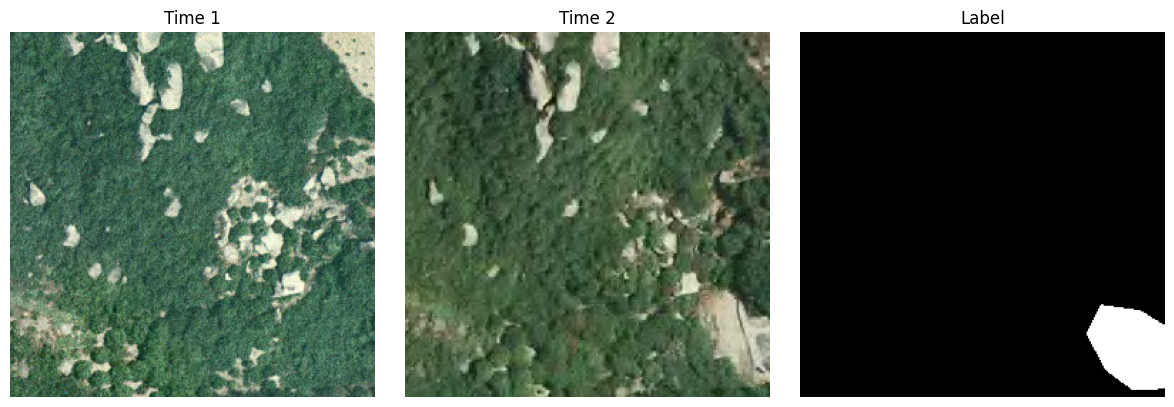

In [167]:
sample = train_dataset[0]
image = sample["image"].numpy()
mask = sample["mask"].squeeze(0).numpy()

time1_img = image[:3].transpose(1, 2, 0)
time2_img = image[3:].transpose(1, 2, 0)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(time1_img)
axes[0].set_title("Time 1")
axes[0].axis("off")

axes[1].imshow(time2_img)
axes[1].set_title("Time 2")
axes[1].axis("off")

axes[2].imshow(mask, cmap="gray")
axes[2].set_title("Label")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Model definition

In [168]:
from transformers import SegformerConfig, SegformerForSemanticSegmentation

In [169]:
class SegFormerBinary(nn.Module):
    def __init__(self, in_channels=6, out_channels=1):
        super().__init__()
        from transformers import SegformerConfig, SegformerForSemanticSegmentation

        segformer_config = SegformerConfig(
            num_channels=in_channels,
            num_labels=out_channels,
            hidden_sizes=[32, 64, 160, 256],
            depths=[2, 2, 2, 2],
            decoder_hidden_size=256,
            reshape_last_stage=True
        )

        self.model = SegformerForSemanticSegmentation(segformer_config)

    def forward(self, x):
        outputs = self.model(pixel_values=x)
        logits = outputs.logits

        # Debug-friendly upsampling for MPS
        logits = F.interpolate(
            logits,
            size=x.shape[-2:],
            mode="nearest"
        )

        logits = logits.contiguous()
        return logits

## 5 — Forward pass test

In [170]:
if device.type == "mps" and CLEAR_MPS_CACHE:
    torch.mps.empty_cache()
    print("Cleared MPS cache.")

model = SegFormerBinary(
    in_channels=config["input_channels"],
    out_channels=config["num_classes"]
).to(device)

sample_batch = next(iter(train_loader))
images = sample_batch["image"].to(device)

with torch.no_grad():
    logits = model(images)

print("Input batch shape:", images.shape)
print("Output logits shape:", logits.shape)

Input batch shape: torch.Size([2, 6, 256, 256])
Output logits shape: torch.Size([2, 1, 256, 256])


## Loss and metrics

In [171]:
def dice_loss(logits, targets, eps=1e-8):
    probs = torch.sigmoid(logits)
    probs = probs.reshape(-1)
    targets = targets.reshape(-1)

    intersection = (probs * targets).sum()
    union = probs.sum() + targets.sum()

    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice


# TEMP DEBUG VERSION:
# first test training stability with BCE only
def bce_dice_loss(logits, targets):
    return F.binary_cross_entropy_with_logits(logits, targets)


def binarize_predictions(logits, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()
    return preds


def compute_confusion_counts(preds, targets):
    preds = preds.reshape(-1)
    targets = targets.reshape(-1)

    tp = ((preds == 1) & (targets == 1)).sum().item()
    fp = ((preds == 1) & (targets == 0)).sum().item()
    fn = ((preds == 0) & (targets == 1)).sum().item()
    tn = ((preds == 0) & (targets == 0)).sum().item()

    return tp, fp, fn, tn


def compute_metrics_from_counts(tp, fp, fn, tn, eps=1e-8):
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    iou = tp / (tp + fp + fn + eps)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou": iou
    }

## Train/validate functions

In [172]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0

    total_batches = len(loader)

    for batch_idx, batch in enumerate(loader, start=1):
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = bce_dice_loss(logits, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        if batch_idx % 50 == 0 or batch_idx == total_batches:
            print(
                f"  Training batch {batch_idx}/{total_batches} "
                f"| Current batch loss: {loss.item():.4f}"
            )

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss


def validate_one_epoch(model, loader, device, threshold=0.5):
    model.eval()
    running_loss = 0.0

    total_tp, total_fp, total_fn, total_tn = 0, 0, 0, 0

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device)
            masks = batch["mask"].to(device)

            logits = model(images)
            loss = bce_dice_loss(logits, masks)

            running_loss += loss.item() * images.size(0)

            preds = binarize_predictions(logits, threshold=threshold)
            tp, fp, fn, tn = compute_confusion_counts(preds, masks)

            total_tp += tp
            total_fp += fp
            total_fn += fn
            total_tn += tn

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics_from_counts(total_tp, total_fp, total_fn, total_tn)

    return epoch_loss, metrics

## Build training model

In [173]:
if device.type == "mps" and CLEAR_MPS_CACHE:
    torch.mps.empty_cache()
    print("Cleared MPS cache before training.")

model = SegFormerBinary(
    in_channels=config["input_channels"],
    out_channels=config["num_classes"]
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

best_val_loss = float("inf")
best_epoch = -1
patience_counter = 0
history = []

num_epochs_to_run = FORMAL_EPOCHS if USE_FORMAL_SUBSET else config["num_epochs"]

print("Model:", config["model_name"])
print("Model save path:", model_save_path)
print("Number of epochs to run:", num_epochs_to_run)

Model: segformer
Model save path: /Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project/outputs/segformer/best_segformer.pt
Number of epochs to run: 10


## Training loop

In [174]:
overall_train_start = time.time()
print("Starting training loop")

for epoch in range(1, num_epochs_to_run + 1):
    print(f"\n===== Epoch {epoch} start =====")
    epoch_start = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    print("train_one_epoch finished")

    val_loss, val_metrics = validate_one_epoch(
        model,
        val_loader,
        device,
        threshold=config["threshold"]
    )
    print("validate_one_epoch finished")

    record = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_iou": val_metrics["iou"]
    }
    history.append(record)

    print(
        f"Epoch {epoch:03d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val IoU: {val_metrics['iou']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | "
        f"Time: {time.time() - epoch_start:.1f}s"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), model_save_path)
        print(f"Saved best model at epoch {epoch}")
    else:
        patience_counter += 1

    if patience_counter >= config["patience"]:
        print(f"Early stopping triggered at epoch {epoch}")
        break

print("Training finished.")
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)
print("Total training time:", time.time() - overall_train_start)

Starting training loop

===== Epoch 1 start =====
  Training batch 50/750 | Current batch loss: 0.6882
  Training batch 100/750 | Current batch loss: 0.4320
  Training batch 150/750 | Current batch loss: 0.3611
  Training batch 200/750 | Current batch loss: 0.3545
  Training batch 250/750 | Current batch loss: 0.3962
  Training batch 300/750 | Current batch loss: 0.5342
  Training batch 350/750 | Current batch loss: 0.4241
  Training batch 400/750 | Current batch loss: 0.7183
  Training batch 450/750 | Current batch loss: 0.3137
  Training batch 500/750 | Current batch loss: 0.3695
  Training batch 550/750 | Current batch loss: 0.4793
  Training batch 600/750 | Current batch loss: 0.2523
  Training batch 650/750 | Current batch loss: 0.4530
  Training batch 700/750 | Current batch loss: 0.6619
  Training batch 750/750 | Current batch loss: 0.3156
train_one_epoch finished
validate_one_epoch finished
Epoch 001 | Train Loss: 0.4745 | Val Loss: 0.4286 | Val IoU: 0.1611 | Val F1: 0.2775 | T

## Save history and plot

   epoch  train_loss  val_loss  val_precision  val_recall    val_f1   val_iou
0      1    0.474457  0.428617       0.763848    0.169540  0.277490  0.161096
1      2    0.419338  0.434877       0.646901    0.237426  0.347363  0.210187
2      3    0.400968  0.381963       0.662474    0.419109  0.513412  0.345362
3      4    0.386721  0.390653       0.593222    0.510288  0.548639  0.378017
4      5    0.384195  0.372008       0.671065    0.476015  0.556957  0.385960


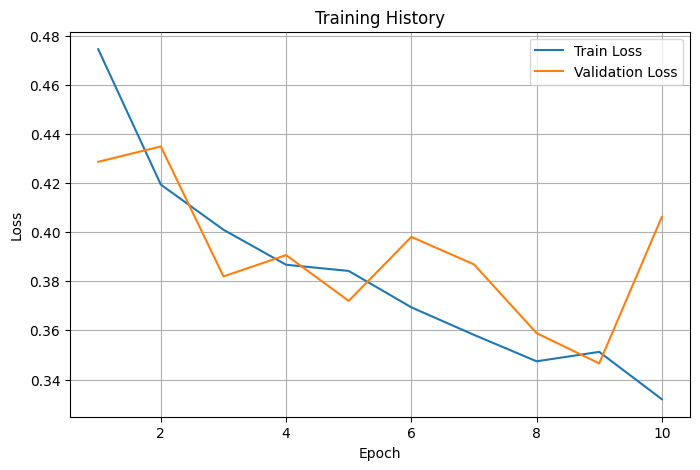

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

project_root = Path.cwd().resolve().parent

history_df = pd.read_csv(project_root / "outputs" / "segformer" / "training_history.csv")
print(history_df.head())

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training History")
plt.legend()
plt.grid(True)
plt.show()



## Load best model

In [13]:
from pathlib import Path
import yaml
import torch
import torch.nn as nn
import torch.nn.functional as F

# ---------------------------------------------------------
# Define SegFormer model
# ---------------------------------------------------------
class SegFormerBinary(nn.Module):
    def __init__(self, in_channels=6, out_channels=1):
        super().__init__()
        from transformers import SegformerConfig, SegformerForSemanticSegmentation

        segformer_config = SegformerConfig(
            num_channels=in_channels,
            num_labels=out_channels,
            hidden_sizes=[32, 64, 160, 256],
            depths=[2, 2, 2, 2],
            decoder_hidden_size=256,
            reshape_last_stage=True
        )

        self.model = SegformerForSemanticSegmentation(segformer_config)

    def forward(self, x):
        outputs = self.model(pixel_values=x)
        logits = outputs.logits

        logits = F.interpolate(
            logits,
            size=x.shape[-2:],
            mode="nearest"
        )

        logits = logits.contiguous()
        return logits

# ---------------------------------------------------------
# Basic setup
# ---------------------------------------------------------
project_root = Path.cwd().resolve().parent

config_path = project_root / "configs" / "segformer.yaml"
with open(config_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

output_dir = project_root / config["output_dir"]
model_save_path = output_dir / config["model_save_name"]

CLEAR_MPS_CACHE = config.get("clear_mps_cache", True)
FORCE_SEGFORMER_CPU = config.get("force_segformer_cpu", False)

# ---------------------------------------------------------
# Device selection
# ---------------------------------------------------------
if FORCE_SEGFORMER_CPU:
    device = torch.device("cpu")
else:
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")

print("Using device:", device)
print("Model save path:", model_save_path)

# ---------------------------------------------------------
# Optional cache clear
# ---------------------------------------------------------
if device.type == "mps" and CLEAR_MPS_CACHE:
    torch.mps.empty_cache()
    print("Cleared MPS cache before test evaluation.")

# ---------------------------------------------------------
# Load best checkpoint
# ---------------------------------------------------------
best_model = SegFormerBinary(
    in_channels=config["input_channels"],
    out_channels=config["num_classes"]
).to(device)

best_model.load_state_dict(torch.load(model_save_path, map_location=device))
best_model.eval()

print("Loaded best model successfully.")

Using device: cpu
Model save path: /Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project/outputs/segformer/best_segformer.pt
Loaded best model successfully.


## Test evaluation

In [16]:
from pathlib import Path
import yaml
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

project_root = Path.cwd().resolve().parent

# ---------------------------------------------------------
# Load config
# ---------------------------------------------------------
config_path = project_root / "configs" / "segformer.yaml"
with open(config_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

data_root = project_root / config["data_root"]
subset_dir = project_root / "data" / "subsets"
subset_test_file = subset_dir / f"subset_test_{config['formal_test_samples']}.txt"

# ---------------------------------------------------------
# Basic image readers
# ---------------------------------------------------------
def read_rgb_image(path):
    img = Image.open(path).convert("RGB")
    return np.array(img, dtype=np.float32) / 255.0

def read_mask(path):
    mask = Image.open(path).convert("L")
    mask = np.array(mask, dtype=np.float32)
    mask = (mask > 0).astype(np.float32)
    return mask

# ---------------------------------------------------------
# Minimal test dataset using existing subset file only
# ---------------------------------------------------------
class FixedSubsetTestDataset(Dataset):
    def __init__(self, root_dir, split, subset_file):
        self.root_dir = Path(root_dir)
        self.split = split

        self.split_dir = self.root_dir / split
        self.time1_dir = self.split_dir / "time1"
        self.time2_dir = self.split_dir / "time2"
        self.label_dir = self.split_dir / "label"

        if not subset_file.exists():
            raise ValueError(f"Missing subset file: {subset_file}")

        with open(subset_file, "r", encoding="utf-8") as f:
            subset_ids = [line.strip() for line in f if line.strip()]

        self.sample_ids = []
        for sample_id in subset_ids:
            file_name = f"{sample_id}.png"

            if not (self.time1_dir / file_name).exists():
                continue
            if not (self.time2_dir / file_name).exists():
                continue
            if not (self.label_dir / file_name).exists():
                continue

            self.sample_ids.append(file_name)

    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
        file_name = self.sample_ids[idx]

        img_t1 = read_rgb_image(self.time1_dir / file_name)
        img_t2 = read_rgb_image(self.time2_dir / file_name)
        mask = read_mask(self.label_dir / file_name)

        image_6ch = np.concatenate([img_t1, img_t2], axis=-1)

        image_tensor = torch.tensor(image_6ch).permute(2, 0, 1).float()
        mask_tensor = torch.tensor(mask).unsqueeze(0).float()

        return {
            "image": image_tensor,
            "mask": mask_tensor,
            "id": file_name.replace(".png", "")
        }

# ---------------------------------------------------------
# Build test dataset and loader
# ---------------------------------------------------------
test_dataset = FixedSubsetTestDataset(
    root_dir=data_root,
    split=config["test_split"],
    subset_file=subset_test_file
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=0
)

print("Using subset file:", subset_test_file)
print("Final test dataset size:", len(test_dataset))
print("Number of test batches:", len(test_loader))

Using subset file: /Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project/data/subsets/subset_test_500.txt
Final test dataset size: 500
Number of test batches: 250


In [19]:
import torch
import torch.nn.functional as F

def binarize_predictions(logits, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()
    return preds

def compute_confusion_counts(preds, targets):
    preds = preds.reshape(-1)
    targets = targets.reshape(-1)

    tp = ((preds == 1) & (targets == 1)).sum().item()
    fp = ((preds == 1) & (targets == 0)).sum().item()
    fn = ((preds == 0) & (targets == 1)).sum().item()
    tn = ((preds == 0) & (targets == 0)).sum().item()

    return tp, fp, fn, tn

def compute_metrics_from_counts(tp, fp, fn, tn, eps=1e-8):
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    iou = tp / (tp + fp + fn + eps)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou": iou
    }

In [21]:
import time
import pandas as pd

total_tp, total_fp, total_fn, total_tn = 0, 0, 0, 0
total_inference_time = 0.0
total_images = 0

with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)

        start_time = time.perf_counter()
        logits = best_model(images)
        end_time = time.perf_counter()

        total_inference_time += (end_time - start_time)
        total_images += images.size(0)

        preds = binarize_predictions(logits, threshold=config["threshold"])
        tp, fp, fn, tn = compute_confusion_counts(preds, masks)

        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_tn += tn

test_metrics = compute_metrics_from_counts(total_tp, total_fp, total_fn, total_tn)

param_count = sum(p.numel() for p in best_model.parameters())
param_count_million = param_count / 1e6
avg_inference_time_ms = (total_inference_time / total_images) * 1000

print("Test metrics:", test_metrics)
print("Parameter count (M):", param_count_million)
print("Average inference time per image (ms):", avg_inference_time_ms)

Test metrics: {'precision': 0.7049326944740337, 'recall': 0.6683284666149678, 'f1': 0.6861427333461753, 'iou': 0.5222353739378679}
Parameter count (M): 3.719105
Average inference time per image (ms): 151.97874359134585


##  Save final metrics

In [22]:
import pandas as pd

metrics_df = pd.DataFrame([{
    "model": config["model_name"],
    "iou": test_metrics["iou"],
    "f1": test_metrics["f1"],
    "precision": test_metrics["precision"],
    "recall": test_metrics["recall"],
    "params_m": param_count_million,
    "inference_time_ms": avg_inference_time_ms
}])

metrics_df.to_csv(output_dir / "metrics.csv", index=False)
metrics_df.head()

,model,iou,f1,precision,recall,params_m,inference_time_ms
0,segformer,0.522235,0.686143,0.704933,0.668328,3.719105,151.978744


## Save shared test IDs

In [23]:
shared_test_ids = []

for i in range(min(20, len(test_dataset))):
    sample = test_dataset[i]
    shared_test_ids.append(sample["id"])

with open(output_dir / "shared_test_ids.txt", "w", encoding="utf-8") as f:
    for sample_id in shared_test_ids:
        f.write(sample_id + "\n")

print("Saved shared test IDs:")
print(shared_test_ids[:10])

Saved shared test IDs:
['00006', '00021', '00066', '00067', '00077', '00083', '00106', '00107', '00115', '00116']


## Save predictions and visuals

In [24]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

test_predictions_dir = output_dir / "test_predictions"
sample_visuals_dir = output_dir / "sample_visuals"

test_predictions_dir.mkdir(parents=True, exist_ok=True)
sample_visuals_dir.mkdir(parents=True, exist_ok=True)

best_model.eval()

num_visual_samples = min(config["num_visual_samples"], len(test_dataset))

for i in range(num_visual_samples):
    sample = test_dataset[i]

    image = sample["image"].unsqueeze(0).to(device)
    mask = sample["mask"].squeeze(0).numpy()
    sample_id = sample["id"]

    with torch.no_grad():
        logits = best_model(image)
        pred = binarize_predictions(logits, threshold=config["threshold"])

    pred_mask = pred.squeeze().cpu().numpy().astype(np.uint8) * 255

    pred_img = Image.fromarray(pred_mask)
    pred_img.save(test_predictions_dir / f"{sample_id}_pred.png")

    image_np = sample["image"].numpy()
    time1_img = image_np[:3].transpose(1, 2, 0)
    time2_img = image_np[3:].transpose(1, 2, 0)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(time1_img)
    axes[0].set_title("Time 1")
    axes[0].axis("off")

    axes[1].imshow(time2_img)
    axes[1].set_title("Time 2")
    axes[1].axis("off")

    axes[2].imshow(mask, cmap="gray")
    axes[2].set_title("Ground Truth")
    axes[2].axis("off")

    axes[3].imshow(pred_mask, cmap="gray")
    axes[3].set_title("Prediction")
    axes[3].axis("off")

    plt.tight_layout()
    plt.savefig(sample_visuals_dir / f"{sample_id}_visual.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

print("Saved predictions and sample visuals successfully.")

Saved predictions and sample visuals successfully.


## Preview one saved visualization

Number of saved visualizations: 10


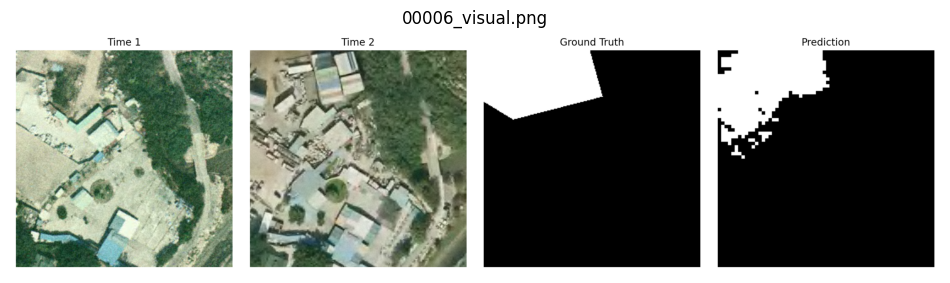

In [25]:
saved_visuals = sorted(sample_visuals_dir.glob("*.png"))

print("Number of saved visualizations:", len(saved_visuals))

if len(saved_visuals) > 0:
    preview_img = Image.open(saved_visuals[0])
    plt.figure(figsize=(12, 4))
    plt.imshow(preview_img)
    plt.axis("off")
    plt.title(saved_visuals[0].name)
    plt.show()

## Show output files

In [26]:
print("Output directory:", output_dir)
print()

for path in sorted(output_dir.rglob("*")):
    print(path.relative_to(project_root))

Output directory: /Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project/outputs/segformer

outputs/segformer/best_segformer.pt
outputs/segformer/config_used.yaml
outputs/segformer/metrics.csv
outputs/segformer/sample_visuals
outputs/segformer/sample_visuals/00006_visual.png
outputs/segformer/sample_visuals/00021_visual.png
outputs/segformer/sample_visuals/00024_visual.png
outputs/segformer/sample_visuals/00066_visual.png
outputs/segformer/sample_visuals/00067_visual.png
outputs/segformer/sample_visuals/00077_visual.png
outputs/segformer/sample_visuals/00079_visual.png
outputs/segformer/sample_visuals/00080_visual.png
outputs/segformer/sample_visuals/00083_visual.png
outputs/segformer/sample_visuals/00105_visual.png
outputs/segformer/shared_test_ids.txt
outputs/segformer/test_predictions
outputs/segformer/test_predictions/00006_pred.png
outputs/segformer/test_predictions/00021_pred.png
outputs/segformer/test_predictions/00024_pred.png
outputs/segformer/test_predictions/